In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from glob import glob
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# to import logger, VR-wide constants and device paths
sys.path.append(os.path.join('.', ".."))
from baseVR.base_logger import CustomLogger as Logger
from baseVR.base_functionality import device_paths

import mea1k_modules.mea1k_visualizations as vis
from mea1k_utils import load_impedance_data as load_impedance_data
from mea1k_connectivity_scripts.analyze_extSine_connectivity import extract_connectivity, vis_connectivity, create_implant_dir
from mea1k_connectivity_scripts.analyze_shortcut_stim import plot_amplitude_ridges, connected_islands, plot_3x3_short_results

nas_dir = device_paths()[0]

In [3]:
L = Logger()
L.init_logger(None, None, "WARNING")

Logging at level WARNING


In [4]:
nas_dir = device_paths()[0]
implant_name = "260703_MEA1K23_S844pad8shankB1"
headstage_name = "MEA1K23"
subdir = f"devices/headstage_devices/{headstage_name}/recordings"

In [5]:
headstage_name = "MEA1K23"
bonding_date = '260713'
HEADSTAGE_DEVICE_NAME = 'MEA1K23'
ELECTRODE_DEVICE_NAME = 'J1688pad2shank'
batch = 1
IMPLANT_DEVICE_NAME = f"{bonding_date}_{HEADSTAGE_DEVICE_NAME}_{ELECTRODE_DEVICE_NAME}B{batch}"

subdir = f"devices/headstage_devices/{headstage_name}/recordings"
impl_subdir = f"devices/implant_devices/{IMPLANT_DEVICE_NAME}/recordings"
nas_dir = device_paths()[0]

In [121]:
merged = []
for dac_offset in [-20,-10,-8,-5,-4,-2,-1,0,1,2,4,5,8,10,20]:
    rec_dir = f"2026_07-14_13.40_Imp2_PT2_LC_102KResistor_DAC{dac_offset}"
    
    # load impedance data
    aggr_df, _, _ = load_impedance_data(rec_dir, nas_dir, impl_subdir, implant_name)
    aggr_df = aggr_df.loc[:, ['electrode', 'amplitude_uV', 'impedance_Ohm', 'external_current_uA', 
                          'external_current_pre_DC_offset', 'external_current_DC_offset', 
                          'external_impedance_Ohm']]
    aggr_df['dac_offset'] = dac_offset
    merged.append(aggr_df)
    
aggr_df = pd.concat(merged, ).reset_index(drop=True)
aggr_df

Loading implant mapping from /mnt/SpatialSequenceLearning/devices/implant_devices/260703_MEA1K23_S844pad8shankB1/bonding/bonding_mapping_260703_MEA1K23_S844pad8shankB1.csv...
Loading implant mapping from /mnt/SpatialSequenceLearning/devices/implant_devices/260703_MEA1K23_S844pad8shankB1/bonding/bonding_mapping_260703_MEA1K23_S844pad8shankB1.csv...
Loading implant mapping from /mnt/SpatialSequenceLearning/devices/implant_devices/260703_MEA1K23_S844pad8shankB1/bonding/bonding_mapping_260703_MEA1K23_S844pad8shankB1.csv...
Loading implant mapping from /mnt/SpatialSequenceLearning/devices/implant_devices/260703_MEA1K23_S844pad8shankB1/bonding/bonding_mapping_260703_MEA1K23_S844pad8shankB1.csv...
Loading implant mapping from /mnt/SpatialSequenceLearning/devices/implant_devices/260703_MEA1K23_S844pad8shankB1/bonding/bonding_mapping_260703_MEA1K23_S844pad8shankB1.csv...
Loading implant mapping from /mnt/SpatialSequenceLearning/devices/implant_devices/260703_MEA1K23_S844pad8shankB1/bonding/bond

,electrode,amplitude_uV,impedance_Ohm,external_current_uA,external_current_pre_DC_offset,external_current_DC_offset,external_impedance_Ohm,dac_offset
0,9747,17425.851817,114863.095635,0.000138,0.110523,0.261902,1.260299e+08,-20
1,4916,16678.898997,109939.530686,0.000135,0.072657,0.261919,1.234938e+08,-20
2,6456,106780.889586,703849.869796,0.000135,0.032868,0.261890,7.901455e+08,-20
3,6675,5433.265250,35813.552908,0.001340,0.025781,0.025378,4.053961e+06,-20
4,8216,15355.734250,101217.845200,0.000129,0.041536,0.261902,1.191334e+08,-20
...,...,...,...,...,...,...,...,...
550,18212,15274.958489,113023.003184,0.000133,0.011521,-0.261916,1.149248e+08,20
551,18213,5582.215844,41304.125283,0.001126,0.035112,0.033035,4.959103e+06,20
552,18433,14684.190969,108651.775637,0.000128,0.017090,-0.261845,1.144918e+08,20
553,16672,15225.424967,112656.493031,0.000133,0.019684,-0.261922,1.147704e+08,20


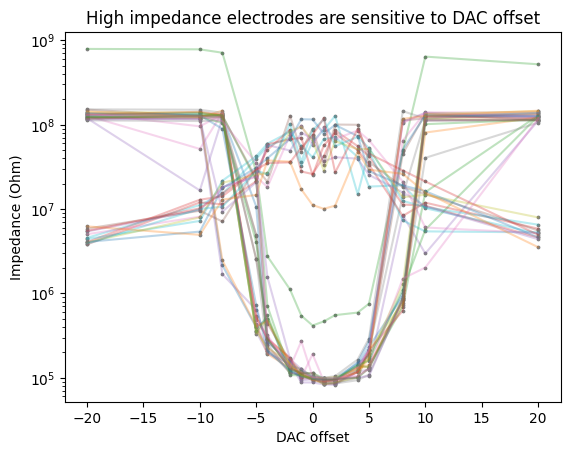

In [122]:
# imp_key = 'impedance_Ohm'
imp_key = 'external_impedance_Ohm'

# iter dac_offset values
for dac_offset in aggr_df['dac_offset'].unique():
    subset = aggr_df[aggr_df['dac_offset'] == dac_offset]
    plt.scatter(np.ones(len(subset)) * dac_offset, subset[imp_key], s=3, color='gray')
    
# connect the points per electrode with a line
for el in aggr_df['electrode'].unique():
    subset = aggr_df[aggr_df['electrode'] == el]
    plt.plot(subset['dac_offset'], subset[imp_key], alpha=.3)
plt.yscale('log')
plt.xlabel('DAC offset')
plt.ylabel('Impedance (Ohm)')
plt.title(f'High impedance electrodes are sensitive to DAC offset')
plt.show()
# small column-wise plot: one DAC offset per subplot
dac_offsets = sorted(aggr_df['dac_offset'].unique())
ncols = len(dac_offsets)


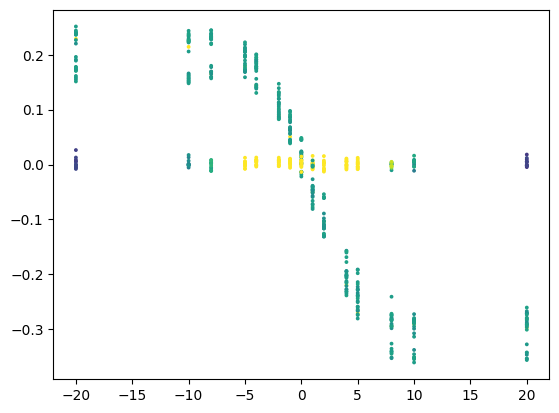

In [123]:
key = 'external_current_pre_DC_offset'
key2 = 'external_current_DC_offset'

# plot over dac_offset values, color according to impedance
for dac_offset in dac_offsets:
    subset = aggr_df[aggr_df['dac_offset'] == dac_offset]
    values = subset[key2] - subset[key]
    plt.scatter(np.ones(len(subset)) * dac_offset, values, s=3, 
                c=subset['impedance_Ohm'], cmap='viridis', vmin=1_000, vmax=2_00_000)

In [142]:
# load old impedance data for comparison to check degredataion through DC current
rec_dir = "2026-07-13_18.57_JDesignFirstSoldered2_Imp1_PT2_LC_102KResistor" # now in implant_name dir
log_scale = True

aggr_df_old, _, _ = load_impedance_data(rec_dir, nas_dir, impl_subdir, implant_name)
# aggr_df_old = aggr_df_old[aggr_df_old['connectivity'] > .9]
# dac0_df_old = aggr_df_old[aggr_df_old['stim_unit'].isin([0, 5, 11, 16,29])].sort_values('electrode').reset_index(drop=True)
dac0_df_old = aggr_df_old
dac0_df_old


Loading implant mapping from /mnt/SpatialSequenceLearning/devices/implant_devices/260703_MEA1K23_S844pad8shankB1/bonding/bonding_mapping_260703_MEA1K23_S844pad8shankB1.csv...


,Unnamed: 0,stim_unit,stim_mode,LSB_nA,electrode,dac_id,stim_sequence_DAC_amplitude,stim_sequence_frequency_Hz,stim_sequence_ncycles,connectivity,amplitude_uV,current_uA,external_current_uA,impedance_Ohm,external_impedance_Ohm,phase_shift_deg,shank_id,mea1k_connectivity,pad_metal
0,0,0,large_current,50.569918,13703,0,3,1000,400,0.373722,151239.500466,0.151710,0.015722,9.969003e+05,9.619709e+06,-8.884259,NaN,0.006289,NaN
1,0,0,large_current,50.569918,8235,0,3,1000,400,0.743198,246407.472256,0.151710,0.078080,1.624203e+06,3.155825e+06,-0.888786,NaN,0.008789,NaN
2,0,0,large_current,50.569918,11100,0,3,1000,400,0.481214,248609.601663,0.151710,0.046540,1.638719e+06,5.341792e+06,1.170812,NaN,0.011857,NaN
3,0,0,large_current,50.569918,11116,0,3,1000,400,0.715929,238024.898583,0.151710,0.050536,1.568949e+06,4.710033e+06,0.799519,NaN,0.007762,NaN
4,0,0,large_current,50.569918,9751,0,3,1000,400,0.682573,235756.866753,0.151710,0.060109,1.553999e+06,3.922161e+06,4.418345,NaN,0.019582,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
643,0,31,large_current,45.423650,13785,0,3,1000,400,0.735781,131264.694987,0.136271,0.008484,9.632625e+05,1.547279e+07,3.108949,NaN,0.008089,NaN
644,0,31,large_current,45.423650,13781,0,3,1000,400,0.935912,14951.045104,0.136271,0.156486,1.097156e+05,9.554219e+04,9.581619,NaN,0.009191,NaN
645,0,31,large_current,45.423650,11125,0,3,1000,400,0.597333,130405.016516,0.136271,0.005220,9.569539e+05,2.498297e+07,2.862142,NaN,0.005221,NaN
646,0,31,large_current,45.423650,22776,0,3,1000,400,0.864322,125031.668928,0.136271,0.009241,9.175226e+05,1.353044e+07,3.826812,NaN,0.003518,NaN


In [135]:
dac0_df

,electrode,amplitude_uV,impedance_Ohm,external_current_uA,external_current_pre_DC_offset,external_current_DC_offset,external_impedance_Ohm,dac_offset
0,4285,241276.895037,1.829347e+06,0.003708,0.026490,0.022135,6.507059e+07,0
1,4639,16839.594124,1.078949e+05,0.174848,0.025773,0.039363,9.631004e+04,0
2,4916,16688.087811,1.100001e+05,0.167064,0.105213,0.106138,9.989017e+04,0
3,4921,16771.664809,1.105510e+05,0.167417,0.025056,0.034205,1.001791e+05,0
4,4930,16761.101740,1.104814e+05,0.169688,0.071879,0.095970,9.877584e+04,0
5,5140,16454.909636,1.084631e+05,0.086430,0.067339,0.053900,1.903838e+05,0
6,5150,236241.022538,1.791166e+06,0.004143,0.110111,0.112416,5.702731e+07,0
7,5312,15938.460474,1.021211e+05,0.172193,0.026490,0.047987,9.256167e+04,0
8,6173,16770.207497,1.074503e+05,0.169826,0.032502,0.053695,9.874948e+04,0
9,6456,72238.440207,4.761621e+05,0.173513,0.024888,0.025135,4.163295e+05,0


array([ 4285,  4639,  4916,  4921,  4930,  5140,  5150,  5312,  6173,
        6456,  6675,  6857,  7361,  8001,  8216,  8896,  8912,  9747,
       11027, 11246, 11247, 11967, 16672, 18204, 18212, 18213, 18309,
       18433, 19618, 19622, 19841, 19981, 20427, 21144, 22907, 22910,
       24465])

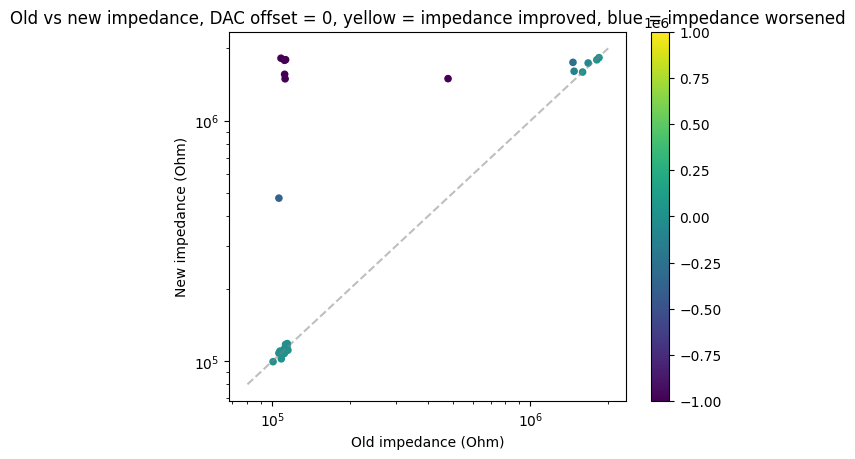

In [136]:
dac0_df = aggr_df[aggr_df['dac_offset'] == 0].sort_values('electrode').reset_index(drop=True)
# color by difference in impedance between old and new measurements
sc = plt.scatter(dac0_df_old.impedance_Ohm, dac0_df.impedance_Ohm, s=20, 
                 c=dac0_df_old.impedance_Ohm.values - dac0_df.impedance_Ohm.values, 
                 cmap='viridis', vmin=-1_000_000, vmax=1_000_000)
# add colorbar
plt.colorbar(sc)
plt.plot([80_000, 2_000_000], [80_000, 2_000_000], color='gray', linestyle='--', alpha=.5)

plt.title('Old vs new impedance, DAC offset = 0, yellow = impedance improved, blue = impedance worsened')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Old impedance (Ohm)')
plt.ylabel('New impedance (Ohm)')

dac0_df.electrode.values

In [137]:
# load old impedance data for comparison to check degredataion through DC current
rec_dir = "2026-07-14_19.19_JDesignFirstSoldered2_Imp1_PT2_LC_102KResistor_test" # now in implant_name dir
log_scale = True

dac0_df_new, _, _ = load_impedance_data(rec_dir, nas_dir, impl_subdir, implant_name)
# aggr_df_old = aggr_df_old[aggr_df_old['connectivity'] > .9]
# dac0_df_old = aggr_df_old[aggr_df_old['stim_unit'].isin([0, 5, 11, 16,29])]
dac0_df_new




Loading implant mapping from /mnt/SpatialSequenceLearning/devices/implant_devices/260703_MEA1K23_S844pad8shankB1/bonding/bonding_mapping_260703_MEA1K23_S844pad8shankB1.csv...


,Unnamed: 0,stim_unit,stim_mode,LSB_nA,electrode,dac_id,stim_sequence_DAC_amplitude,stim_sequence_frequency_Hz,stim_sequence_ncycles,connectivity,...,current_uA,external_current_uA,external_current_pre_DC_offset,external_current_DC_offset,impedance_Ohm,external_impedance_Ohm,phase_shift_deg,shank_id,mea1k_connectivity,pad_metal
0,0,1,large_current,49.820683,9494,0,3,1000,400,0.963491,...,0.149462,0.170122,0.033723,0.032094,1.117174e+05,9.815017e+04,8.698074,NaN,0.013016,NaN
1,0,1,large_current,49.820683,2028,0,3,1000,400,0.970563,...,0.149462,0.175896,0.039369,0.024810,1.093176e+05,9.288945e+04,8.867964,7.0,0.296485,1.0
2,0,1,large_current,49.820683,9069,0,3,1000,400,0.967126,...,0.149462,0.170125,0.028687,0.008592,1.091749e+05,9.591481e+04,8.955032,NaN,0.043414,NaN
3,0,1,large_current,49.820683,3793,0,3,1000,400,0.986878,...,0.149462,0.005034,0.046541,0.049983,1.578121e+06,4.685636e+07,-7.542407,NaN,0.004002,NaN
4,0,1,large_current,49.820683,2037,0,3,1000,400,0.954790,...,0.149462,0.172845,0.036470,0.010550,1.096267e+05,9.479605e+04,8.764507,6.0,0.007507,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,0,23,large_current,44.639621,10764,0,3,1000,400,0.934769,...,0.133919,0.157875,0.033723,0.061422,1.069394e+05,9.071222e+04,8.888612,2.0,0.008620,2.0
123,0,23,large_current,44.639621,10983,0,3,1000,400,0.947732,...,0.133919,0.158486,0.039979,0.062732,1.050421e+05,8.875941e+04,8.759836,2.0,0.006668,2.0
124,0,23,large_current,44.639621,10963,0,3,1000,400,0.950352,...,0.133919,0.158997,0.045091,0.067214,1.129120e+05,9.510301e+04,8.765322,2.0,0.006677,2.0
125,0,23,large_current,44.639621,10737,0,3,1000,400,0.912364,...,0.133919,0.151328,0.038530,0.060886,1.129484e+05,9.995480e+04,8.858727,NaN,0.004857,NaN


/tmp/ipykernel_3521577/1658629185.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  electrodes = dac0_df_new[dac0_df_old['electrode'].isin(dac0_df_new['electrode'])].electrode.values


Text(0, 0.5, 'New impedance (Ohm)')

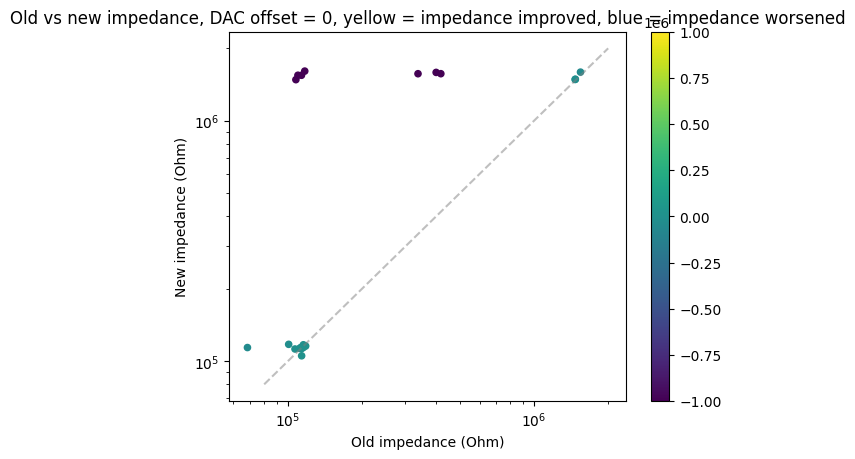

In [151]:
# common electrodes

dac0_df_new
dac0_df_old
electrodes = dac0_df_new[dac0_df_old['electrode'].isin(dac0_df_new['electrode'])].electrode.values
electrodes

plt.scatter(dac0_df_old.set_index('electrode').loc[electrodes, 'impedance_Ohm'], dac0_df_new.set_index('electrode').loc[electrodes, 'impedance_Ohm'], s=20, 
            c=dac0_df_old.set_index('electrode').loc[electrodes, 'impedance_Ohm'].values - dac0_df_new.set_index('electrode').loc[electrodes, 'impedance_Ohm'].values,
            cmap='viridis', vmin=-1_000_000, vmax=1_000_000)
plt.colorbar()
plt.plot([80_000, 2_000_000], [80_000, 2_000_000], color='gray', linestyle='--', alpha=.5)
plt.title('Old vs new impedance, DAC offset = 0, yellow = impedance improved, blue = impedance worsened')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Old impedance (Ohm)')
plt.ylabel('New impedance (Ohm)')